0
Delivery_Status
On Time       89936
Super Late     3764
Unknown        2971
Late           2770
Name: count, dtype: int64
Late rate: 6.8 %


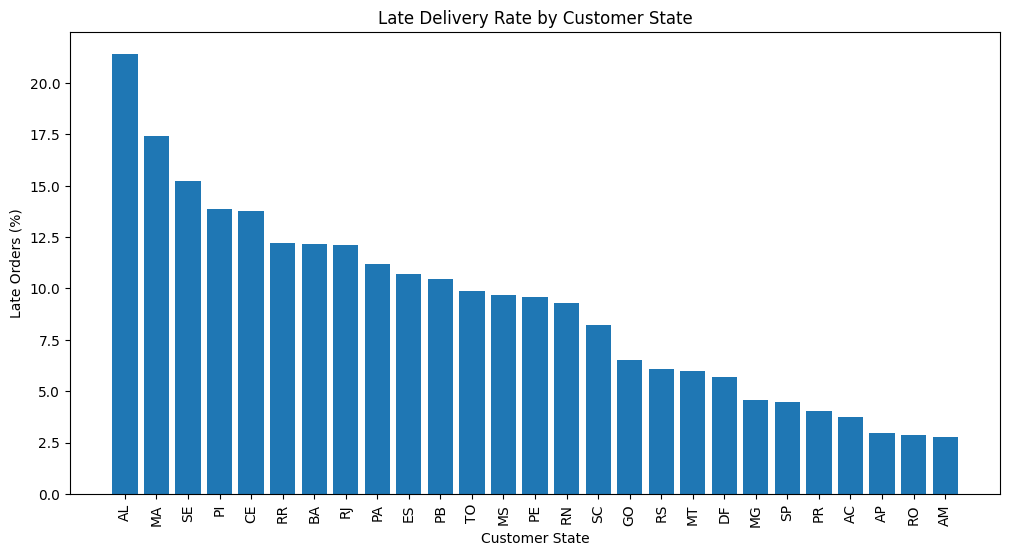

region
South           5.9
Southeast       6.1
Center-West     6.5
North           8.6
Northeast      12.7
Name: Is_Late, dtype: float64
Distance vs late %: 0.06
Days early vs late %: -0.7


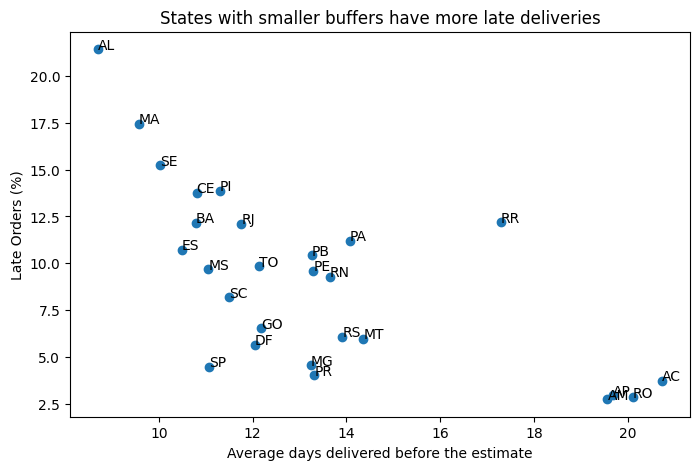

Delivery_Status
On Time       4.29
Late          2.99
Super Late    1.74
Name: review_score, dtype: float64


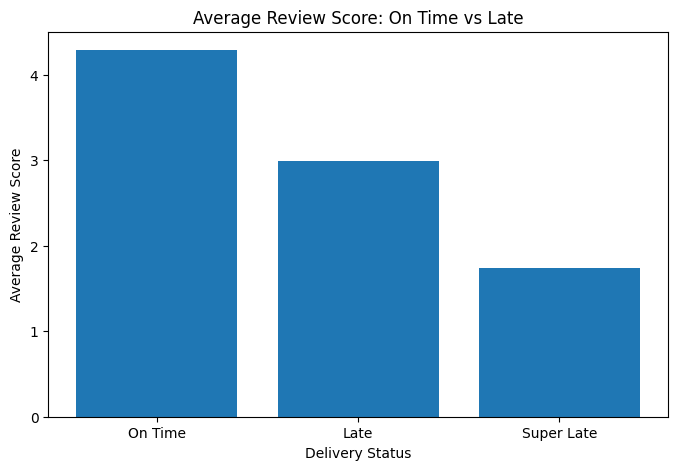

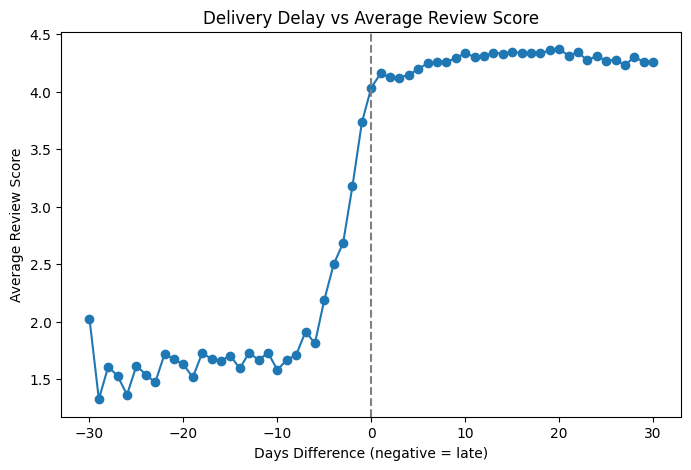

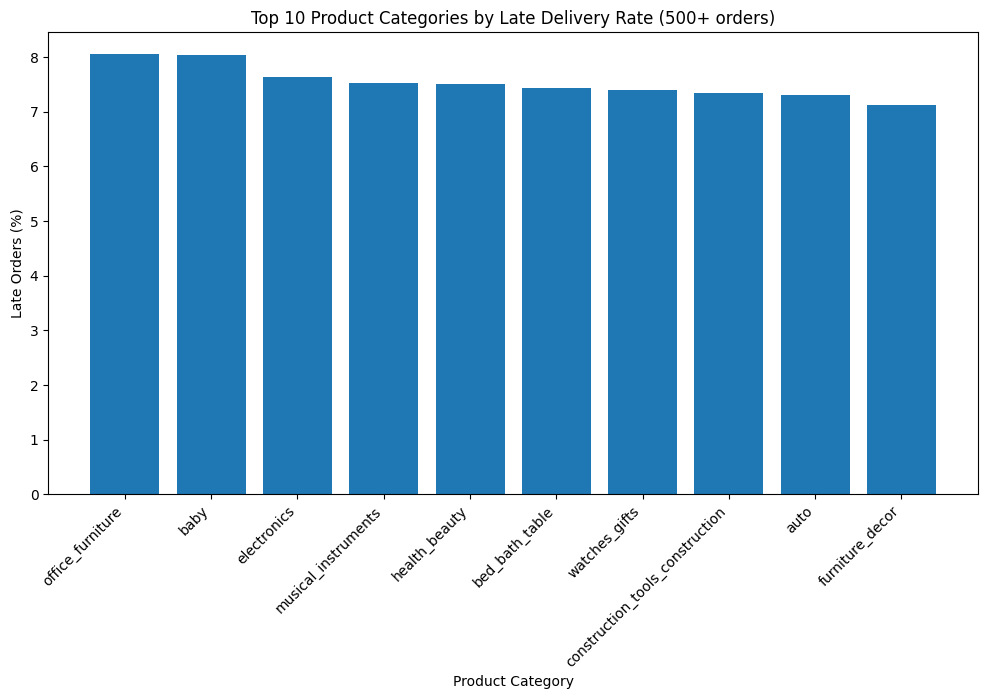

Delay_Owner
Carrier    72.2
Seller     27.8
Name: proportion, dtype: float64


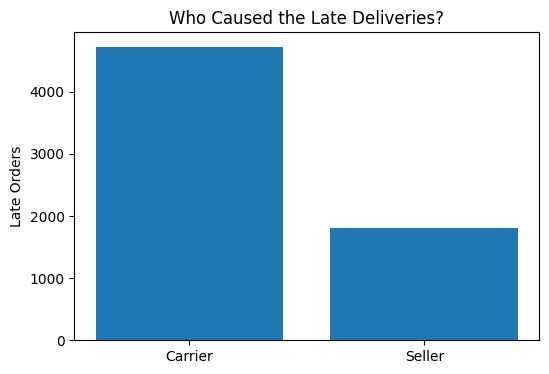

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("olist_orders_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv", dtype={"customer_zip_code_prefix": str})
products = pd.read_csv("olist_products_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv", dtype={"seller_zip_code_prefix": str})
geo = pd.read_csv("olist_geolocation_dataset.csv", dtype={"geolocation_zip_code_prefix": str})

reviews = (
    reviews.sort_values("review_answer_timestamp")
    .drop_duplicates(subset="order_id", keep="last")
)

master = orders.merge(
    reviews,
    on="order_id",
    how="left"
).merge(
    customers,
    on="customer_id",
    how="left"
)

print(master["order_id"].duplicated().sum())

master["order_estimated_delivery_date"] = pd.to_datetime(
    master["order_estimated_delivery_date"]
)

master["order_delivered_customer_date"] = pd.to_datetime(
    master["order_delivered_customer_date"]
)

master["Days_Difference"] = (
    master["order_estimated_delivery_date"].dt.normalize()
    - master["order_delivered_customer_date"].dt.normalize()
).dt.days

master.loc[master["order_status"] != "delivered", "Days_Difference"] = np.nan

def delivery_status(days):
    if pd.isna(days):
        return "Unknown"
    elif days < -5:
        return "Super Late"
    elif days < 0:
        return "Late"
    else:
        return "On Time"

master["Delivery_Status"] = master["Days_Difference"].apply(delivery_status)

master["Is_Late"] = master["Days_Difference"] < 0

delivered_orders = master.dropna(subset=["Days_Difference"]).copy()
print(master["Delivery_Status"].value_counts())
print("Late rate:", round(delivered_orders["Is_Late"].mean() * 100, 1), "%")

state_late_rate = (
    delivered_orders
    .groupby("customer_state")["Is_Late"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(state_late_rate.index, state_late_rate.values)
plt.xlabel("Customer State")
plt.ylabel("Late Orders (%)")
plt.title("Late Delivery Rate by Customer State")
plt.xticks(rotation=90)
plt.show()

regions = {
    "AC": "North", "AP": "North", "AM": "North", "PA": "North", "RO": "North", "RR": "North", "TO": "North",
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast", "MA": "Northeast", "PB": "Northeast",
    "PE": "Northeast", "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",
    "DF": "Center-West", "GO": "Center-West", "MT": "Center-West", "MS": "Center-West",
    "ES": "Southeast", "MG": "Southeast", "RJ": "Southeast", "SP": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
}
delivered_orders["region"] = delivered_orders["customer_state"].map(regions)
print(delivered_orders.groupby("region")["Is_Late"].mean().mul(100).round(1).sort_values())

zip_locations = geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].mean()

def distance_km(lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = np.radians(lat1), np.radians(lng1), np.radians(lat2), np.radians(lng2)
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lng2 - lng1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

trips = (
    order_items.merge(sellers, on="seller_id")
    .merge(master[["order_id", "customer_zip_code_prefix"]], on="order_id")
    .merge(zip_locations, left_on="seller_zip_code_prefix", right_index=True)
    .merge(zip_locations, left_on="customer_zip_code_prefix", right_index=True, suffixes=("_seller", "_customer"))
)
trips["km"] = distance_km(trips["geolocation_lat_seller"], trips["geolocation_lng_seller"],
                          trips["geolocation_lat_customer"], trips["geolocation_lng_customer"])
delivered_orders = delivered_orders.merge(trips.groupby("order_id")["km"].mean(), on="order_id", how="left")

state_summary = delivered_orders.groupby("customer_state").agg(
    late_pct=("Is_Late", "mean"),
    avg_km=("km", "mean"),
    avg_days_early=("Days_Difference", "mean"),
)
print("Distance vs late %:", round(state_summary["avg_km"].corr(state_summary["late_pct"], method="spearman"), 2))
print("Days early vs late %:", round(state_summary["avg_days_early"].corr(state_summary["late_pct"], method="spearman"), 2))

plt.figure(figsize=(8, 5))
plt.scatter(state_summary["avg_days_early"], state_summary["late_pct"] * 100)
for state in state_summary.index:
    plt.text(state_summary.loc[state, "avg_days_early"], state_summary.loc[state, "late_pct"] * 100, state)
plt.xlabel("Average days delivered before the estimate")
plt.ylabel("Late Orders (%)")
plt.title("States with smaller buffers have more late deliveries")
plt.show()

average_review = (
    delivered_orders.groupby("Delivery_Status")["review_score"]
    .mean()
    .reindex(["On Time", "Late", "Super Late"])
)
print(average_review.round(2))

plt.figure(figsize=(8, 5))
plt.bar(average_review.index, average_review.values)
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.title("Average Review Score: On Time vs Late")
plt.show()

delay_review = (
    delivered_orders.groupby(delivered_orders["Days_Difference"].clip(-30, 30))["review_score"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(delay_review.index, delay_review.values, marker="o")
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("Days Difference (negative = late)")
plt.ylabel("Average Review Score")
plt.title("Delivery Delay vs Average Review Score")
plt.show()

missing = pd.DataFrame({
    "product_category_name": ["pc_gamer", "portateis_cozinha_e_preparadores_de_alimentos"],
    "product_category_name_english": ["pc_gamer", "kitchen_portables"],
})
translation = pd.concat([translation, missing])

products_translated = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

order_products = (
    order_items.merge(products_translated, on="product_id", how="left")
    [["order_id", "product_category_name_english"]]
    .drop_duplicates()
    .merge(delivered_orders[["order_id", "Is_Late"]], on="order_id")
)

category_stats = order_products.groupby("product_category_name_english").agg(
    orders=("order_id", "count"),
    late_rate=("Is_Late", "mean"),
)
category_late_rate = (
    category_stats[category_stats["orders"] >= 500]["late_rate"]
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
plt.bar(
    category_late_rate.head(10).index,
    category_late_rate.head(10).values
)
plt.xlabel("Product Category")
plt.ylabel("Late Orders (%)")
plt.title("Top 10 Product Categories by Late Delivery Rate (500+ orders)")
plt.xticks(rotation=45, ha="right")
plt.show()

deadline = order_items.groupby("order_id")["shipping_limit_date"].max().reset_index()
deadline["shipping_limit_date"] = pd.to_datetime(deadline["shipping_limit_date"])
delivered_orders = delivered_orders.merge(deadline, on="order_id", how="left")
delivered_orders["order_delivered_carrier_date"] = pd.to_datetime(delivered_orders["order_delivered_carrier_date"])

def who_was_late(row):
    if not row["Is_Late"]:
        return "Not late"
    elif row["order_delivered_carrier_date"] > row["shipping_limit_date"]:
        return "Seller"
    else:
        return "Carrier"

delivered_orders["Delay_Owner"] = delivered_orders.apply(who_was_late, axis=1)
late_orders = delivered_orders[delivered_orders["Is_Late"]]
print(late_orders["Delay_Owner"].value_counts(normalize=True).mul(100).round(1))

plt.figure(figsize=(6, 4))
plt.bar(late_orders["Delay_Owner"].value_counts().index, late_orders["Delay_Owner"].value_counts().values)
plt.ylabel("Late Orders")
plt.title("Who Caused the Late Deliveries?")
plt.show()

delivered_orders["state_iso"] = "BR-" + delivered_orders["customer_state"]
delivered_orders["Is_Late"] = delivered_orders["Is_Late"].astype(int)
delivered_orders.to_csv("logistics_master.csv", index=False)

In [ ]:
looker = delivered_orders[["order_id", "order_purchase_timestamp", "customer_state", "state_iso", "region",
                           "review_score", "Days_Difference", "Delivery_Status", "Is_Late", "Delay_Owner"]]
looker.to_csv("looker_data.csv", index=False)